# Customer Segmentation with RFM Analysis

This notebook applies **RFM (Recency, Frequency, Monetary) analysis** to segment customers based on purchasing behavior. By quantifying how recently, how often, and how much customers spend, we can uncover actionable insights into customer value and engagement.


- **Identify high-value vs. low-value customers** to prioritize retention and acquisition strategies  
- **Understand behavioral patterns** across segments for more personalized marketing  
- **Estimate customer lifetime value (CLTV proxy)** using RFM scores as predictors  
- **Design targeted strategies** for each segment to maximize ROI  

## RFM Dimensions
- **Recency (R):** How recently a customer made a purchase  
- **Frequency (F):** How often they purchase within a given period  
- **Monetary (M):** How much revenue they generate  

## Why RFM?
RFM analysis is a proven framework for customer segmentation in e-commerce and retail. It helps businesses:
- Pinpoint loyal customers worth nurturing  
- Detect at-risk customers who need re-engagement  
- Identify one-time or low-value buyers for cost-efficient targeting  
- Align marketing spend with customer value  


## Data Preparation



In [3]:
import pandas as pd
import numpy as np

# -----------------------------
# Load Data
# -----------------------------
orders = pd.read_csv('../data/raw/orders.csv')

# -----------------------------
# Preprocessing
# -----------------------------
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Define snapshot date (one day after the last purchase)
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

# -----------------------------
# RFM Calculation
# -----------------------------
rfm = orders.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',                                    # Frequency
    'final_price': 'sum'                                    # Monetary
})

# Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index for clean DataFrame
rfm.reset_index(inplace=True)

# -----------------------------
# Preview Results
# -----------------------------
print(rfm.head())


   customer_id  Recency  Frequency  Monetary
0            7       39          1  13042.84
1           10      155          2  83765.49
2           12       71          1   5096.94
3           14      111          1   5312.96
4           18       26          2   3797.53


# RFM Scoring Framework

To transform raw RFM metrics into actionable insights, each customer is assigned a score from **1 to 5** across the three dimensions:

- **Recency (R):** Measures how recently a customer purchased.  
  - Lower values (recent buyers) receive higher scores.  
- **Frequency (F):** Captures how often a customer makes purchases.  
  - Higher purchase counts receive higher scores.  
- **Monetary (M):** Reflects the total spending of a customer.  
  - Higher spenders receive higher scores.  

By combining these three scores into a composite **RFM score** (e.g., `543`), we can classify customers into meaningful segments such as *Champions*, *Loyal Customers*, *At Risk*, or *Hibernating*. This scoring framework enables targeted marketing strategies and efficient resource allocation.


In [4]:
# -----------------------------
# RFM Scoring
# -----------------------------

# Recency Score: Customers who purchased more recently get higher scores (5 = most recent)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency Score: Customers with more purchases get higher scores (5 = most frequent)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetary Score: Customers who spend more get higher scores (5 = highest spenders)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Composite RFM Score: Concatenate R, F, M scores into a single string (e.g., "543")
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

# Preview results
print(rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 
           'R_score', 'F_score', 'M_score', 'RFM_score']].head())


   customer_id  Recency  Frequency  Monetary R_score F_score M_score RFM_score
0            7       39          1  13042.84       4       1       3       413
1           10      155          2  83765.49       1       4       5       145
2           12       71          1   5096.94       3       1       2       312
3           14      111          1   5312.96       2       1       2       212
4           18       26          2   3797.53       5       4       2       542


# Customer Segmentation Based on RFM Scores

Using the composite **RFM score**, customers are classified into strategic segments.  
Each segment reflects a different level of engagement and value, enabling tailored marketing actions.

## Key Segments
- **Champions** → High Recency, Frequency, and Monetary scores  
  *Most valuable customers: recent, frequent, and high spenders. Prioritize retention and reward programs.*  

- **Loyal Customers** → High Frequency and strong Monetary scores  
  *Consistent buyers who generate steady revenue. Strengthen loyalty through exclusive offers and personalized experiences.*  

- **At Risk** → Low Recency but historically high Frequency/Monetary scores  
  *Previously valuable customers who haven’t purchased recently. Target with reactivation campaigns and win-back strategies.*  

- **Lost Customers** → Low Recency, Frequency, and Monetary scores  
  *Inactive or disengaged customers. Limit marketing spend; consider low-cost re-engagement or remove from active campaigns.*  


In [5]:
# -----------------------------
# Customer Segmentation Function
# -----------------------------
def segment_customer(row):
    # Champions: Very recent purchasers with high frequency
    if row['R_score'] == 5 and row['F_score'] >= 4:
        return 'Champions'
    
    # Loyal Customers: High frequency buyers (consistent spenders)
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    
    # At Risk: Customers who haven’t purchased recently but had good past activity
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    
    # Lost Customers: Low recency, low frequency, and low monetary value
    else:
        return 'Lost Customers'

# Apply segmentation to RFM DataFrame
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Preview results
print(rfm[['customer_id', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment']].head())


   customer_id R_score F_score M_score RFM_score          Segment
0            7       4       1       3       413   Lost Customers
1           10       1       4       5       145  Loyal Customers
2           12       3       1       2       312   Lost Customers
3           14       2       1       2       212   Lost Customers
4           18       5       4       2       542        Champions


# Segment Distribution

Understanding the **distribution of customers across segments** helps quantify the impact of each group and prioritize marketing efforts.  

By calculating the percentage of customers in each segment, we can identify where most of the customer base lies and allocate resources accordingly.

## Example Insights
- **Champions:** Typically a small but highly valuable group.  
- **Loyal Customers:** Often the largest segment, driving consistent revenue.  
- **At Risk:** A critical group to monitor for churn prevention.  
- **Lost Customers:** May represent a significant portion, but with limited ROI potential.  

Visualizing this distribution (e.g., with a bar chart or pie chart) provides stakeholders with a clear picture of customer engagement and value concentration.


In [7]:
# -----------------------------
# Segment Distribution
# -----------------------------

# Calculate percentage distribution of customers across segments
segment_dist = (
    rfm['Segment']
    .value_counts(normalize=True) * 100
)

# Round values safely
segment_dist = segment_dist.round(2)

# Preview results
print(segment_dist)


Segment
Lost Customers     52.71
Loyal Customers    32.01
Champions           7.94
At Risk             7.34
Name: proportion, dtype: float64


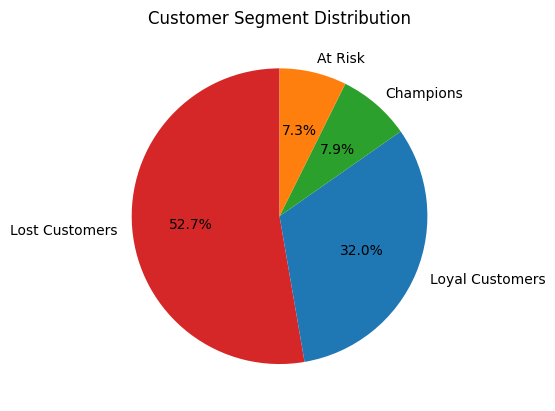

In [12]:
import matplotlib.pyplot as plt


# Pie chart
segment_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                  colors=['#d62728','#1f77b4','#2ca02c','#ff7f0e'])
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()


# 📊 Customer Segment Summary

## Insight
- Majority of customers are **Lost (52.7%)**, indicating high churn.  
- **Loyal Customers (32%)** form a strong base.  
- **Champions (7.9%)** are few but highly valuable.  
- **At Risk (7.3%)** need immediate attention to prevent churn.  

## Recommendation
- **Lost** → Launch win-back campaigns and analyze churn drivers.  
- **Loyal** → Strengthen retention with loyalty rewards and upsell opportunities.  
- **Champions** → Provide VIP perks and leverage them as brand advocates.  
- **At Risk** → Target with personalized offers and proactive engagement.  

## Decision
- Prioritize **retention strategy** to reduce Lost share.  
- Invest in **nurturing Loyal and Champions** for sustainable growth.  
- Implement **early intervention programs** for At Risk customers to minimize future churn.  

---

# Segment Distribution

Analyzing the **percentage of customers in each segment** provides a clear view of customer base composition.  
This helps stakeholders understand where most customers fall and guides resource allocation:

- **Champions:** Small but highly valuable group worth prioritizing.  
- **Loyal Customers:** Often the largest segment, driving consistent revenue.  
- **At Risk:** Important to monitor for churn prevention.  
- **Lost Customers:** May represent a significant portion but with limited ROI potential.  

Visualizing this distribution (e.g., bar chart or pie chart) makes the segmentation story more compelling.


In [8]:
# -----------------------------
# Top Customer Revenue Contribution
# -----------------------------

# Sort customers by Monetary value (descending)
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)

# Define top 20% of customers
top_20 = int(0.2 * len(rfm_sorted))
top_customers = rfm_sorted.head(top_20)

# Calculate revenue share contributed by top 20% customers
top_revenue_share = (
    top_customers['Monetary'].sum() / rfm['Monetary'].sum()
).round(4)  # Rounded for clarity

# Preview result
print(f"Top 20% customers contribute {top_revenue_share:.2%} of total revenue")


Top 20% customers contribute 57.51% of total revenue


# 💡 Customer Revenue Distribution Insight

## Insight
- The **top 20% of customers contribute 57.51% of total revenue**.  
- This indicates a **Pareto effect (80/20 rule)** where a small fraction of customers drive the majority of business value.  

## Recommendation
- **Prioritize high-value customers** with personalized engagement, loyalty rewards, and premium services.  
- **Segment marketing spend**: allocate more resources to nurture and retain these top contributors.  
- **Upsell and cross-sell** opportunities should be focused on this group to maximize ROI.  

## Decision
- Build a **VIP program** for the top 20% to strengthen retention and advocacy.  
- Monitor revenue concentration risk — diversify by converting mid-tier customers into higher-value segments.  
- Make **data-driven investments** in customer experience for this high-impact group.  

---

# Segment Analysis

To extract actionable insights, we analyze customer behavior across segments.  
This comparison highlights differences in **recency, frequency, and monetary value**, helping identify where to focus retention, reactivation, and growth strategies.

## Key Focus Areas
- **Champions:** Evaluate their share of revenue and engagement trends.  
- **Loyal Customers:** Assess consistency in purchase frequency and opportunities for upselling.  
- **At Risk:** Monitor declining recency and design win-back campaigns.  
- **Lost Customers:** Quantify their proportion and decide on cost-effective re-engagement strategies.  

## Analytical Approach
- Compare **average RFM metrics** across segments.  
- Measure **revenue contribution** by each segment.  
- Track **segment transitions over time** to identify churn or growth patterns.  

This analysis provides a **strategic lens** on customer value distribution, guiding targeted marketing and resource allocation.


In [9]:
# -----------------------------
# Segment-Level Analysis
# -----------------------------

# Calculate average RFM metrics for each segment
segment_analysis = (
    rfm.groupby('Segment')
       .agg({
           'Recency': 'mean',
           'Frequency': 'mean',
           'Monetary': 'mean'
       })
       .round(2)  # Round values for clarity
       .sort_values(by='Monetary', ascending=False)  # Optional: sort by revenue
)

# Preview results
print(segment_analysis)


                 Recency  Frequency  Monetary
Segment                                      
Champions          14.32       2.42  43754.38
Loyal Customers    94.46       1.98  35635.15
Lost Customers     81.74       1.00  16516.73
At Risk           144.16       1.00  12569.66


# 📊 Segment-Level Analysis

## Insight
- **Champions**: Lowest recency (14 days), highest frequency (2.42), and highest monetary value (₹43,754). They are highly engaged and spend the most.  
- **Loyal Customers**: Moderate recency (94 days), good frequency (1.98), and strong monetary contribution (₹35,635). They are consistent but less recent.  
- **Lost Customers**: Recency ~82 days, low frequency (1.0), and moderate spend (₹16,517). They have churned and contribute less.  
- **At Risk**: Highest recency (144 days), lowest frequency (1.0), and lowest monetary value (₹12,570). They are disengaged and at high risk of churn.  

## Recommendation
- **Champions** → Maintain engagement with VIP programs, exclusive offers, and referral incentives.  
- **Loyal Customers** → Strengthen retention with loyalty rewards and upsell opportunities.  
- **Lost Customers** → Deploy win-back campaigns and analyze churn drivers.  
- **At Risk** → Target with personalized reactivation offers before they churn further.  

## Decision
- **Prioritize Champions and Loyal Customers** for growth and advocacy.  
- **Design retention strategies** to reduce Lost and At Risk segments.  
- **Balance acquisition with retention** by focusing resources on high-value customers while reactivating disengaged ones.  

---


# Customer Lifetime Value (CLTV) Analysis – Proxy

To estimate customer value, we use a **proxy measure** based on **Monetary** and **Frequency** scores.  
This approach highlights customers who not only spend more but also purchase more often, serving as a practical approximation of lifetime value.

## Why CLTV Matters
- **Revenue Forecasting:** Identifies customers likely to generate the most future revenue.  
- **Retention Prioritization:** Helps focus efforts on high-value customers.  
- **Marketing ROI:** Guides resource allocation toward segments with the greatest long-term impact.  

## Proxy Approach
- **Frequency:** Indicates engagement and repeat purchase behavior.  
- **Monetary:** Reflects spending capacity and contribution to revenue.  
- **CLTV Proxy:** A combined metric (e.g., `Frequency × Monetary`) used to rank customers by potential lifetime value.  

This proxy provides a **quick, actionable view** of customer value distribution, enabling targeted strategies without requiring complex predictive modeling.


In [10]:
# -----------------------------
# CLTV Proxy Calculation
# -----------------------------

# Estimate CLTV proxy as Frequency × Monetary
rfm['CLTV_proxy'] = rfm['Monetary'] * rfm['Frequency']

# Segment-level analysis: average CLTV proxy per segment
cltv_analysis = (
    rfm.groupby('Segment')['CLTV_proxy']
       .mean()
       .round(2)  # Round for readability
       .sort_values(ascending=False)  # Optional: sort by value
)

# Preview results
print(cltv_analysis)


Segment
Champions          117452.74
Loyal Customers     79106.60
Lost Customers      16516.73
At Risk             12569.66
Name: CLTV_proxy, dtype: float64


# 📈 CLTV Proxy Analysis

## Insight
- **Champions** drive the highest CLTV proxy (₹117,452), confirming their outsized long-term value.  
- **Loyal Customers** contribute significantly (₹79,107), forming a stable revenue backbone.  
- **Lost Customers** (₹16,517) and **At Risk** (₹12,570) have much lower CLTV proxies, reflecting disengagement and churn.  
- Revenue concentration is evident: a small group (Champions + Loyal) accounts for the majority of projected lifetime value.  


## Recommendation
- **Champions** → Protect and expand their value with VIP programs, exclusive rewards, and advocacy initiatives.  
- **Loyal Customers** → Strengthen retention and encourage upsell/cross-sell to move them closer to Champion status.  
- **Lost Customers** → Deploy targeted win-back campaigns; analyze churn drivers to reduce future losses.  
- **At Risk** → Immediate reactivation offers and personalized engagement to prevent further decline.  


## Decision
- **Prioritize Champions and Loyal Customers** for retention and growth strategies.  
- **Invest in proactive engagement** for At Risk customers to minimize churn.  
- **Allocate marketing spend strategically**: more towards high-value segments, while testing cost-effective win-back for Lost customers.  

---

# 📊 Consolidated Business Insights

## Insight
- **High churn**: Over 50% of customers are lost, showing weak retention.  
- **Revenue concentration**: Top 20% of customers contribute ~58% of revenue, confirming Pareto dynamics.  
- **Segment value gap**: Champions and Loyal Customers drive the majority of CLTV and monetary value, while Lost and At Risk segments contribute little.  
- **Engagement signals**: Champions are recent and frequent buyers; At Risk customers show long inactivity and low spend.  

## Recommendation
- **Retention focus**: Reduce churn by reactivating At Risk and Lost customers with targeted campaigns.  
- **VIP strategy**: Invest in Champions and Loyal Customers through loyalty programs, upsell/cross-sell, and advocacy initiatives.  
- **Revenue diversification**: Convert mid-tier customers into higher-value segments to reduce dependency on top 20%.  
- **Data-driven personalization**: Use RFM and CLTV insights to tailor offers and allocate marketing spend efficiently.  

## Decision
- **Prioritize high-value segments** (Champions + Loyal) for growth and advocacy.  
- **Implement proactive retention** for At Risk customers to minimize future churn.  
- **Design win-back campaigns** for Lost customers to recover revenue.  
- **Strategically allocate resources**: more toward nurturing high-value customers, while testing cost-effective reactivation for low-value segments.  

---